In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
paces_df = pd.DataFrame({
    'name': ['Easy Pace', 'GMP', 'HMP', '10K', '5K','Mile'],
    'intensity':[1,2,3,4,5,6],
    'pace_range': ['8:30-8:00/mile', '6:49/mile', '6:25–6:30/mile', '6:05–6:10/mile', '5:50–5:55/mile','5:20-5:25/mile']
})

training_df = pd.DataFrame({
    'week':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
    'total_mileage':[35,38,42,34,45,50,52,42,58,60,64,66,50,42,32,25],
    'speed_session':['6 × 800m @ 5K', '4 mi tempo @ HMP', '10 × 400m @ 5K', '4 × 1 mi @ HMP', '5 mi tempo @ HMP', '8 × 800m @ 5K', '6 × 1 mi @ HMP', '4 mi tempo @ HMP', '3 × 2 mi @ HMP', '12 × 400m @ 5K', '7 mi tempo @ HMP', '4 × 2 mi @ HMP', '5 mi tempo @ HMP', '6 × 800m @ 5K', '3 × 1 mi @ GMP', 'Light strides'],
    'n_speed_reps':[6,1,10,4,1,8,6,1,3,12,1,4,1,6,3,6],
    'speed_rep_pace_name':['5K','HMP','5K','HMP','HMP','5K','HMP','HMP','HMP','5K','HMP','HMP','HMP','5K','GMP','Mile'],
    'speed_rep_distance (mi)':[.5,4,.25,1,5,.5,1,4,2,.25,7,2,5,.5,1,.06],
    'long_run':['10 Easy', '12 Easy', '14 (last 3 @ GMP)', '11 Easy', '15 (5 @ GMP) - 5 easy, 5 GMP, 5 cooldown', '16 Easy', '18 (6 @ GMP) - 6 easy, 6 GMP, 6 cooldown', '13 Easy', '18 (8 @ GMP) - 5 easy, 8 GMP, 5 cooldown', '20 (last 5 steady ~7:00)', '18 (10 @ GMP) - 4 easy, 10 GMP, 4 cooldown', '22 (last 8 @ GMP)', '15 Easy', '13 (7 @ GMP) - 4 easy, 7 GMP, 2 mile cooldown', '10 Easy', 'Race Day - GET THE JOB DONE'],
    'long_run_distance (mi)':[10,12,14,11,15,16,18,13,18,20,18,22,15,13,10,26.2],
    'long_run_pace_name':[None,None,'GMP',None,'GMP',None,'GMP',None,'GMP','GMP','GMP','GMP',None,'GMP',None,'GMP'],
    'long_run_speed_pace_distance (mi)':[0,0,3,0,5,0,6,0,8,5,10,8,0,7,0,26.2]
})

paces_df

,name,intensity,pace_range
0,Easy Pace,1,8:30-8:00/mile
1,GMP,2,6:49/mile
2,HMP,3,6:25–6:30/mile
3,10K,4,6:05–6:10/mile
4,5K,5,5:50–5:55/mile
5,Mile,6,5:20-5:25/mile


In [ ]:
training_df

,week,total_mileage,speed_session,n_speed_reps,speed_rep_pace_name,speed_rep_distance (mi),long_run,long_run_distance (mi),long_run_pace_name,long_run_speed_pace_distance (mi)
0,1,35,6 × 800m @ 5K,6,5K,0.50,10 Easy,10.0,None,0.0
1,2,38,4 mi tempo @ HMP,1,HMP,4.00,12 Easy,12.0,None,0.0
2,3,42,10 × 400m @ 5K,10,5K,0.25,14 (last 3 @ GMP),14.0,GMP,3.0
3,4,34,4 × 1 mi @ HMP,4,HMP,1.00,11 Easy,11.0,None,0.0
4,5,45,5 mi tempo @ HMP,1,HMP,5.00,"15 (5 @ GMP) - 5 easy, 5 GMP, 5 cooldown",15.0,GMP,5.0
5,6,50,8 × 800m @ 5K,8,5K,0.50,16 Easy,16.0,None,0.0
6,7,52,6 × 1 mi @ HMP,6,HMP,1.00,"18 (6 @ GMP) - 6 easy, 6 GMP, 6 cooldown",18.0,GMP,6.0
7,8,42,4 mi tempo @ HMP,1,HMP,4.00,13 Easy,13.0,None,0.0
8,9,58,3 × 2 mi @ HMP,3,HMP,2.00,"18 (8 @ GMP) - 5 easy, 8 GMP, 5 cooldown",18.0,GMP,8.0
9,10,60,12 × 400m @ 5K,12,5K,0.25,20 (last 5 steady ~7:00),20.0,GMP,5.0


In [ ]:
# To prevent duplicate columns if this cell is run multiple times, we'll create temporary merge dataframes and assign to new columns.

# Prepare paces_df for the speed intensity merge
paces_speed_merge = paces_df[['name', 'intensity']].rename(columns={'name': 'merge_name', 'intensity': 'speed_intensity_temp'})

# Perform the merge for speed intensity
training_df = pd.merge(training_df, paces_speed_merge, left_on='speed_rep_pace_name', right_on='merge_name', how='left')
# Assign the temporary intensity to the final column and clean up temporary merge columns
training_df['speed_intensity'] = training_df['speed_intensity_temp']
training_df = training_df.drop(columns=['merge_name', 'speed_intensity_temp'], errors='ignore')

# Prepare paces_df for the long run intensity merge
paces_long_run_merge = paces_df[['name', 'intensity']].rename(columns={'name': 'merge_name', 'intensity': 'long_run_intensity_temp'})

# Perform the merge for long run intensity
training_df = pd.merge(training_df, paces_long_run_merge, left_on='long_run_pace_name', right_on='merge_name', how='left')
# Assign the temporary intensity to the final column and clean up temporary merge columns
training_df['long_run_intensity'] = training_df['long_run_intensity_temp']
training_df = training_df.drop(columns=['merge_name', 'long_run_intensity_temp'], errors='ignore')

# Fill None values in long_run_intensity with 0
training_df['long_run_intensity'] = training_df['long_run_intensity'].fillna(0)

# Calculate speed_total_workout_distance
training_df['speed_total_workout_distance'] = training_df['n_speed_reps'] * training_df['speed_rep_distance (mi)']

training_df.head()

,week,total_mileage,speed_session,n_speed_reps,speed_rep_pace_name,speed_rep_distance (mi),long_run,long_run_distance (mi),long_run_pace_name,long_run_speed_pace_distance (mi),speed_intensity,long_run_intensity,speed_total_workout_distance
0,1,35,6 × 800m @ 5K,6,5K,0.50,10 Easy,10.0,None,0.0,5,0.0,3.0
1,2,38,4 mi tempo @ HMP,1,HMP,4.00,12 Easy,12.0,None,0.0,3,0.0,4.0
2,3,42,10 × 400m @ 5K,10,5K,0.25,14 (last 3 @ GMP),14.0,GMP,3.0,5,2.0,2.5
3,4,34,4 × 1 mi @ HMP,4,HMP,1.00,11 Easy,11.0,None,0.0,3,0.0,4.0
4,5,45,5 mi tempo @ HMP,1,HMP,5.00,"15 (5 @ GMP) - 5 easy, 5 GMP, 5 cooldown",15.0,GMP,5.0,3,2.0,5.0


Now that the `intensity` information is merged into the `training_df`, I will modify the plotting cell to overlay the intensity on the same chart, using a secondary y-axis for better visualization.

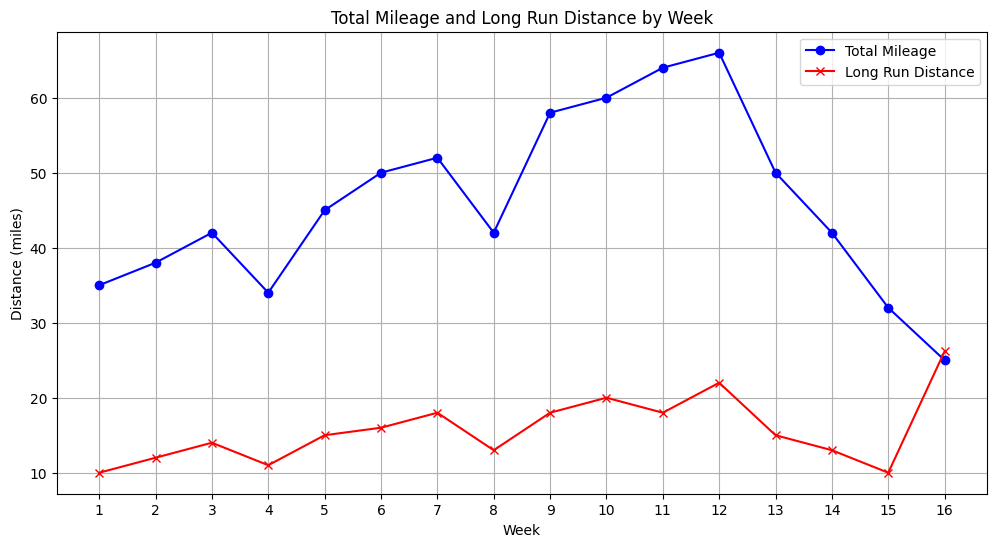

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(training_df['week'], training_df['total_mileage'], marker='o', color='blue', label='Total Mileage')
plt.plot(training_df['week'], training_df['long_run_distance (mi)'], marker='x', color='red', label='Long Run Distance')
plt.title('Total Mileage and Long Run Distance by Week')
plt.xlabel('Week')
plt.ylabel('Distance (miles)')
plt.grid(True)
plt.xticks(training_df['week'])
plt.legend()
plt.show()

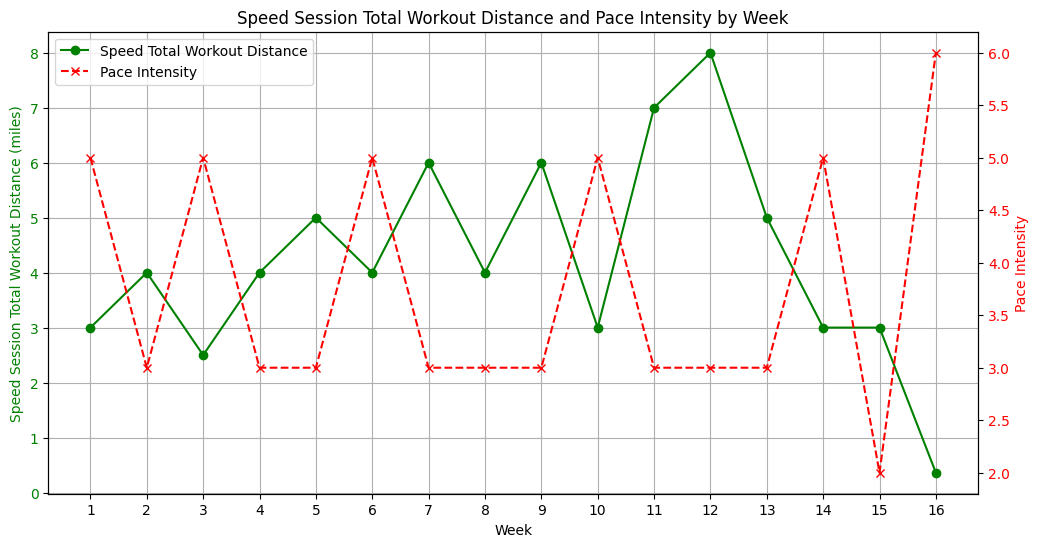

In [ ]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax1.plot(training_df['week'], training_df['speed_total_workout_distance'], marker='o', color='green', label='Speed Total Workout Distance')
ax1.set_title('Speed Session Total Workout Distance and Pace Intensity by Week')
ax1.set_xlabel('Week')
ax1.set_ylabel('Speed Session Total Workout Distance (miles)', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True)

ax2 = ax1.twinx() # Create a secondary y-axis
ax2.plot(training_df['week'], training_df['speed_intensity'], marker='x', color='red', linestyle='--', label='Pace Intensity')
ax2.set_ylabel('Pace Intensity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.xticks(training_df['week'])
plt.show()

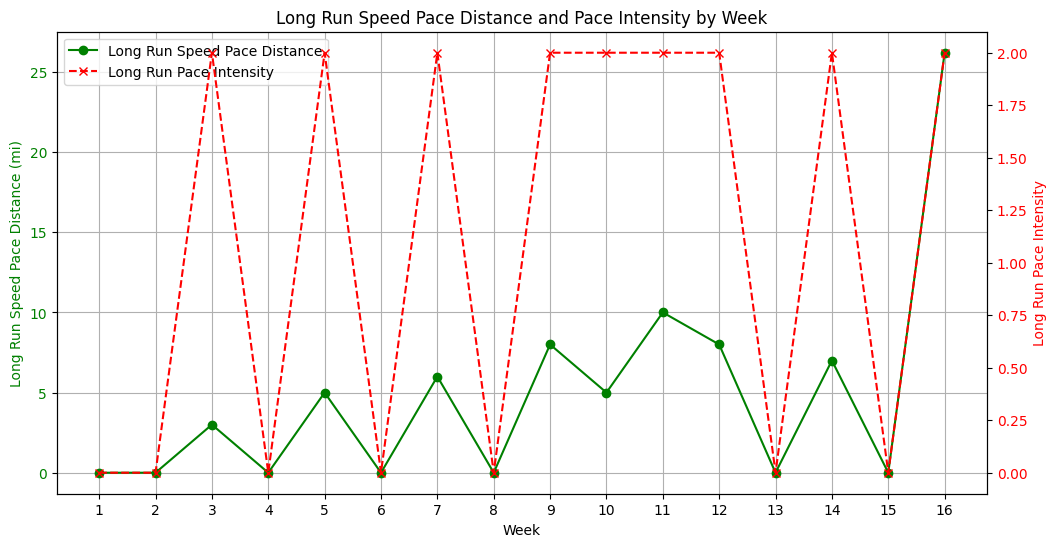

In [ ]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
line1, = ax1.plot(training_df['week'], training_df['long_run_speed_pace_distance (mi)'], marker='o', color='green', label='Long Run Speed Pace Distance')
ax1.set_title('Long Run Speed Pace Distance and Pace Intensity by Week')
ax1.set_xlabel('Week')
ax1.set_ylabel('Long Run Speed Pace Distance (mi)', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True)

ax2 = ax1.twinx() # Create a secondary y-axis
line2, = ax2.plot(training_df['week'], training_df['long_run_intensity'], marker='x', color='red', linestyle='--', label='Long Run Pace Intensity')
ax2.set_ylabel('Long Run Pace Intensity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes by passing the plot handles directly
ax1.legend([line1, line2], ['Long Run Speed Pace Distance', 'Long Run Pace Intensity'], loc='upper left')

plt.xticks(training_df['week'])
plt.show()